In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# A

In [14]:
INITIAL = pd.read_excel('board2.xlsx')

In [15]:
INITIAL['Average'] = INITIAL[['Math',	'Electronics',	'GEAS',	'Communication']].mean(axis=1)
INITIAL

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [16]:
Viscommtemp = INITIAL[(INITIAL['Hometown'] == 'Visayas') & (INITIAL['Track'] == 'Communication')]
Viscommtemp

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
10,S11,Female,Communication,Visayas,48,56,48,67,54.75
11,S12,Male,Communication,Visayas,89,67,84,64,76.00
17,S18,Male,Communication,Visayas,81,40,81,52,63.50
21,S22,Female,Communication,Visayas,64,39,89,58,62.50
27,S28,Male,Communication,Visayas,85,53,80,53,67.75


In [17]:
Viscomm = Viscommtemp[['Name', 'Gender', 'Math', 'Electronics', 'Average']]

In [18]:
display(Viscomm)
print("Total Row Number:", len(Viscomm))

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Total Row Number: 5


# B

In [19]:
VisfemaleTemp = INITIAL[(INITIAL['Gender'] == 'Female') & (INITIAL['Hometown'] == 'Visayas')]
VisfemaleTemp

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
10,S11,Female,Communication,Visayas,48,56,48,67,54.75
20,S21,Female,Microelectronics,Visayas,83,51,68,72,68.50
21,S22,Female,Communication,Visayas,64,39,89,58,62.50
23,S24,Female,Microelectronics,Visayas,85,45,60,41,57.75
25,S26,Female,Instrumentation,Visayas,71,47,83,62,65.75


In [20]:
Visfemale = VisfemaleTemp[['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
display(Visfemale)

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [21]:
display(Visfemale.loc[Visfemale['Average']>=60])

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


# C

In [22]:
avgTrack = INITIAL.groupby('Track')['Average'].mean().reset_index()
avgGender = INITIAL.groupby('Gender')['Average'].mean().reset_index()
avgHometown = INITIAL.groupby('Hometown')['Average'].mean().reset_index()

In [23]:
display(avgTrack)
display(avgGender)
display(avgHometown)

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


,Gender,Average
0,Female,66.616667
1,Male,67.183333


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


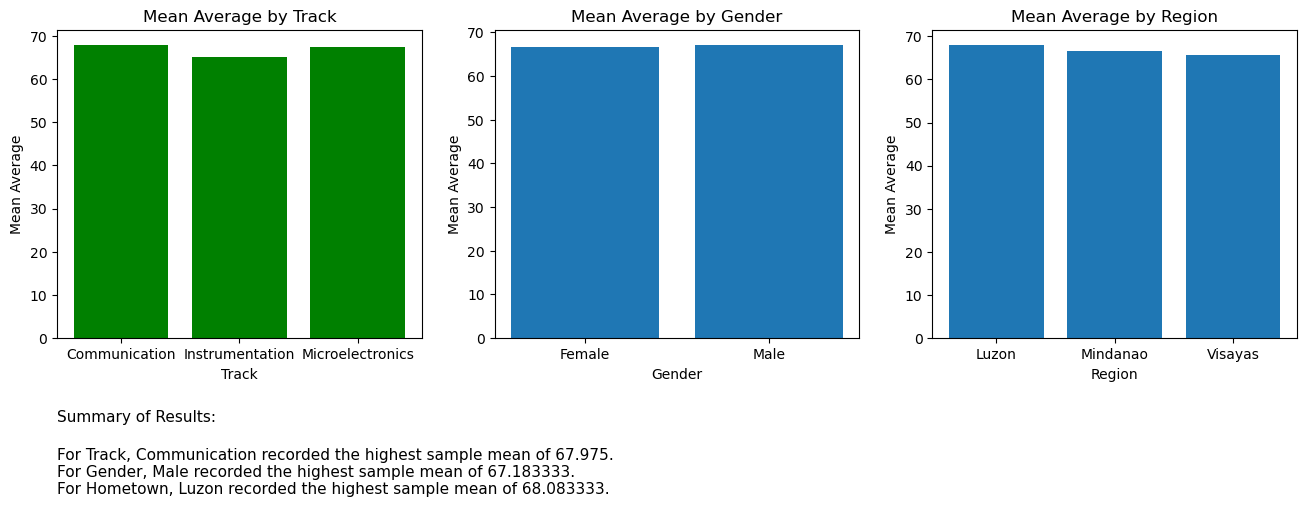

In [28]:
graph, axes = plt.subplots(nrows=1, ncols=3, figsize=(16,4))

axes[0].bar(avgTrack['Track'], avgTrack['Average'],)
axes[0].set(title='Mean Average by Track', xlabel='Track', ylabel='Mean Average',)

axes[1].bar(avgGender['Gender'], avgGender['Average'])
axes[1].set(title='Mean Average by Gender', xlabel='Gender', ylabel='Mean Average')

axes[2].bar(avgHometown['Hometown'], avgHometown['Average'])
axes[2].set(title='Mean Average by Region', xlabel='Region', ylabel='Mean Average')

graph.text(0.125, -0.10, 'Summary of Results:', size=11)
graph.text(0.125, -0.28, 
    'For Track, Communication recorded the highest sample mean of 67.975.\n'
    'For Gender, Male recorded the highest sample mean of 67.183333.\n'
    'For Hometown, Luzon recorded the highest sample mean of 68.083333.', 
    size=11)

plt.show()